# 🚀 Practice Day 04

**📅 Date:** 2026-09-15  
**📁 Category:** Phase 1 · 시각화 기초 (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice the core matplotlib chart types: bar chart and line chart (핵심 차트 유형 연습: bar chart, line chart)
- Choose the right chart type for each business question (질문에 맞는 차트 유형 선택하기)
- (Bonus) Try a pie chart to show category share ((보너스) pie chart로 카테고리 비중 표현해보기)

---
# 📂 Dataset

**Dataset Name:** Cafe Franchise Monthly Sales (카페 프랜차이즈 월별 매출)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** Monthly sales for 8 branches across 3 product categories (Beverage, Dessert, Coffee Beans) over the most recent 12 months (Aug 2025-Jul 2026), 288 rows total. Includes branch, month, category, revenue, and customer count. Branch size and a mild month-over-month growth trend are baked into the numbers.
(8개 지점 x 3개 카테고리(음료/디저트/원두) x 최근 12개월(2025년 8월~2026년 7월) = 288행. 지점, 월, 카테고리, 매출, 방문 고객 수 포함. 지점별 규모 차이와 완만한 월별 성장 추세가 반영되어 있습니다.)

## Dataset Preview

In [10]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)
pd.set_option("display.float_format", "{:,.2f}".format)

branches = ['SoHo', 'Williamsburg', 'Midtown', 'Chelsea', 'Astoria', 'Park Slope', 'Financial District', 'Upper West Side']
branch_multiplier = {b: np.random.uniform(0.7, 1.4) for b in branches}

months = pd.date_range('2025-08-01', periods=12, freq='MS')
categories = ['Beverage', 'Dessert', 'Coffee Beans']
category_base = {'Beverage': 10_000_000, 'Dessert': 4_000_000, 'Coffee Beans': 2_000_000}
category_cust_base = {'Beverage': 1800, 'Dessert': 600, 'Coffee Beans': 150}

rows = []
for branch in branches:
    for m_idx, month in enumerate(months):
        growth = 1 + 0.012 * m_idx  # mild month-over-month growth trend
        for cat in categories:
            revenue = int(category_base[cat] * branch_multiplier[branch] * growth * np.random.normal(1.0, 0.08))
            customer_count = int(category_cust_base[cat] * branch_multiplier[branch] * growth * np.random.normal(1.0, 0.10))
            rows.append({
                'branch': branch,
                'month': month,
                'category': cat,
                'revenue': revenue,
                'customer_count': customer_count,
            })

df = pd.DataFrame(rows)
df.head()

,branch,month,category,revenue,customer_count
0,SoHo,2025-08-01,Beverage,10837367,1864
1,SoHo,2025-08-01,Dessert,3704162,608
2,SoHo,2025-08-01,Coffee Beans,1853013,137
3,SoHo,2025-09-01,Beverage,9925725,1417
4,SoHo,2025-09-01,Dessert,3357426,551


## Dataset Information


In [11]:
# Dataset Information
print(df.shape)
df.info()
df.describe()


(288, 5)
<class 'pandas.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   branch          288 non-null    str           
 1   month           288 non-null    datetime64[us]
 2   category        288 non-null    str           
 3   revenue         288 non-null    int64         
 4   customer_count  288 non-null    int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 11.4 KB


,month,revenue,customer_count
count,288,288.00,288.00
mean,2026-01-15 10:00:00,"5,939,417.33",930.76
min,2025-08-01 00:00:00,"1,236,314.00",100.00
25%,2025-10-24 06:00:00,"2,590,726.75",203.00
50%,2026-01-16 12:00:00,"4,272,723.00",623.00
75%,2026-04-08 12:00:00,"8,739,386.25","1,508.25"
max,2026-07-01 00:00:00,"16,288,928.00","3,075.00"
std,NaN,"4,197,317.71",809.81


---
# ❓ Business Questions

1. What is the total revenue for each branch across the full year? (전 지점의 연간 총 매출은?)
2. Which category generates the most total revenue — Beverage, Dessert, or Coffee Beans? (음료/디저트/원두 중 어떤 카테고리의 매출이 가장 큰가?)
3. What is the total monthly revenue across all branches, and how does it change from month to month? (전체 지점 월별 총 매출은 얼마이며 어떻게 변하는가?)
4. How does total revenue compare across the 8 branches? (8개 지점의 총 매출을 비교하면 어떤 모습인가?)
5. How has total monthly revenue trended over the past 12 months? (지난 12개월간 월별 총 매출 추이는?)

---
# 🛠 Skills Used
- [x] Python
- [x] NumPy — generated the cafe sales table with a fixed seed  
  (고정 seed로 카페 매출 테이블 생성)
- [x] Pandas — `groupby`, `pct_change`, `pivot_table` with margins  
  (groupby, 전월 대비, 합계 있는 피벗)
- [ ] SQL
- [x] Matplotlib — sorted bar chart, monthly line, pie for category share  
  (정렬 막대, 월별 선, 카테고리 파이)
- [ ] Other:


---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0  
  (결측 없음)
- [x] Duplicate Rows — 0  
  (중복 없음)
- [x] Wrong Data Types — `month` is datetime; revenue and customer_count are int  
  (`month`는 datetime, 매출·고객수는 정수)
- [ ] Rename Columns — not needed  
  (불필요)
- [ ] Drop Columns — not needed  
  (불필요)


In [12]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
branch            0
month             0
category          0
revenue           0
customer_count    0
dtype: int64

Duplicate rows: 0

Dtypes
branch                       str
month             datetime64[us]
category                     str
revenue                    int64
customer_count             int64
dtype: object

Column names
['branch', 'month', 'category', 'revenue', 'customer_count']

Text columns — unique counts
branch      8
category    3
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** What is the total revenue for each branch across the full year? (전 지점의 연간 총 매출은?)

**Result:** 12-month totals (KRW): Williamsburg 277.2M, Upper West Side 269.6M, Midtown 250.7M, Chelsea 234.8M, SoHo 194.6M, Park Slope 167.9M, Astoria 167.2M, Financial District 148.6M. Company total **1,710,552,190**.  
(12개월 합. 1위 Williamsburg 2.77억, 꼴찌 Financial District 1.49억. 전체 1,710,552,190원)

**Insight:** The largest store is about **1.9×** the smallest, so one sales target for all eight branches does not fit. “연간” here is these 12 months (Aug 2025–Jul 2026), not calendar 2025 vs 2026 (5 months vs 7 months).  
(1위가 꼴찌의 약 1.9배. 8지점 동일 목표는 안 맞음. 여기 연간은 이 12개월이지, 달력 연도 비교가 아님)


In [13]:
# Question 1: Total revenue per branch, across all months and categories
# (지점별 연간 총 매출 계산)
# "연간" here = the 12 months in this table (2025-08 ~ 2026-07), not calendar 2025 vs 2026
# (여기 연간 = 표에 있는 12개월. 달력 연도 2025/2026으로 쪼개는 게 아님)

branch_revenue = df.groupby("branch")["revenue"].sum().sort_values(ascending=False)
display(branch_revenue)
print(f'{df['revenue'].sum():,}')

# Why not groupby year? 2025 has 5 months, 2026 has 7 months.
# (연도로 나누면 25년 5개월 vs 26년 7개월이라 비교가 안 됨)
# print(df.groupby(df["month"].dt.to_period("Y")).size())


branch
Williamsburg          277201670
Upper West Side       269573796
Midtown               250686213
Chelsea               234755017
SoHo                  194597424
Park Slope            167905779
Astoria               167227580
Financial District    148604711
Name: revenue, dtype: int64

1,710,552,190


## Question 2

**Question:** Which category generates the most total revenue — Beverage, Dessert, or Coffee Beans? (음료/디저트/원두 중 어떤 카테고리의 매출이 가장 큰가?)

**Result:** Beverage **1,076.7M (62.9%)**, Dessert **423.3M (24.7%)**, Coffee Beans **210.5M (12.3%)**. Each category has 96 rows. KRW per customer: Beverage 5,721 / Dessert 6,647 / Coffee Beans 13,026.  
(음료 62.9%, 디저트 24.7%, 원두 12.3%. 행 수는 각 96. 손님 1명당은 원두가 가장 큼)

**Insight:** Beverage is most of the money because of volume, not extra rows. Coffee Beans is last in total KRW but **highest per customer**, so it is a small-ticket-count, high-spend category — not simply “weak.”  
(음료는 손님 수가 많아서 매출 1위. 원두는 총액 3위지만 객단가가 가장 높아서, 그냥 약한 상품은 아님)


In [14]:
# Question 2: Total revenue per category, ranked
# (카테고리별 총 매출 집계 및 순위)

print(df["category"].value_counts())
tbl = (
    df.groupby("category")["revenue"].sum()
      .sort_values(ascending=False)
      .to_frame("revenue")
      .assign(percent=lambda x: (x["revenue"] / x["revenue"].sum() * 100).round(1))
)
display(tbl)

# Extra: KRW per customer = total revenue / total customers
# (추가: 손님 1명당 매출. 행마다 나눈 뒤 sum 하지 말 것)
g = df.groupby("category")[["revenue", "customer_count"]].sum()
g["krw_per_customer"] = g["revenue"] / g["customer_count"]
display(g.sort_values("revenue", ascending=False))


category
Beverage        96
Dessert         96
Coffee Beans    96
Name: count, dtype: int64


,revenue,percent
category,,
Beverage,1076725294,62.90
Dessert,423324576,24.70
Coffee Beans,210502320,12.30


,revenue,customer_count,krw_per_customer
category,,,
Beverage,1076725294,188208,"5,720.93"
Dessert,423324576,63691,"6,646.54"
Coffee Beans,210502320,16160,"13,026.13"


## Question 3

**Question:** What is the total monthly revenue across all branches, and how does it change from month to month? (전체 지점 월별 총 매출은 얼마이며 어떻게 변하는가?)

**Result:** Company monthly revenue **134.7M → 149.2M** KRW (**+10.8%** vs Aug 2025). Peak Jun 2026 152.7M (**+13.4%** vs start). MoM dips: Nov -1.3%, May -2.1%, Jul -2.3%. By branch vs first month: Financial District **+20%**, Park Slope **+15.4%**, most others ~**+10–12%**, SoHo **+0.6%**.  
(전사 1.35억→1.49억, 첫 달 대비 +10.8%. 6월 정점. 11·5·7월은 전월 대비 하락. 지점은 FD +20%, SoHo는 +0.6%로 거의 제자리)

**Insight:** The company trend is a mild rise with noise (±5% MoM), not a crash in the down months. Growth is not even: SoHo is flat while Financial District grew fastest from a small base.  
(전사는 완만 상승+출렁임. 하락 달을 급락으로 보기 어려움. 성장은 지점마다 다름. SoHo는 정체, FD는 작은 매장인데 %로는 가장 오름)


In [15]:
# Question 3: Total revenue per month, summed across all branches and categories
# (월별 전체 지점 총 매출 집계)

month_revenue = df.groupby(df["month"].dt.to_period("M"))["revenue"].sum()
display(month_revenue)

# Month-over-month %  (not cumsum — cumsum is running KRW total)
# (전월 대비 %. cumsum은 쌓인 원 합이라 퍼센트가 아님)
mom_pct = (month_revenue.pct_change() * 100).round(1)
vs_start_pct = ((month_revenue / month_revenue.iloc[0] - 1) * 100).round(1)

month_change = pd.DataFrame({
    "revenue": month_revenue,
    "mom_pct": mom_pct,           # vs previous month
    "vs_start_pct": vs_start_pct, # vs first month (Aug 2025)
})
display(month_change)

# Same idea by branch: first month vs last month, and month-to-month
# (지점별로 같은 비교)
bm = df.groupby(["branch", df["month"].dt.to_period("M")])["revenue"].sum()
mom_by_branch = (bm.groupby("branch").pct_change() * 100).round(1)

start = bm.groupby("branch").first()
end = bm.groupby("branch").last()
branch_12m_pct = ((end / start - 1) * 100).round(1).sort_values(ascending=False)

print("12-month change by branch (% vs first month)")
display(branch_12m_pct)
print("month-over-month % by branch (sample)")
display(mom_by_branch.unstack())

# Totals row + column (the "All" / 총합 feature)
# (합계 행·열. 퍼센트 표가 아니라 원 금액 표에 씀)
tmp = df.assign(month_p=df["month"].dt.to_period("M"))
branch_month_krw = pd.pivot_table(
    tmp,
    index="branch",
    columns="month_p",
    values="revenue",
    aggfunc="sum",
    margins=True,
    margins_name="Total",
)
display(branch_month_krw)


month
2025-08    134653883
2025-09    134687578
2025-10    138835778
2025-11    137005737
2025-12    137478274
2026-01    140606983
2026-02    143937035
2026-03    147081301
2026-04    148713599
2026-05    145632804
2026-06    152706589
2026-07    149212629
Freq: M, Name: revenue, dtype: int64

,revenue,mom_pct,vs_start_pct
month,,,
2025-08,134653883,NaN,0.00
2025-09,134687578,0.00,0.00
2025-10,138835778,3.10,3.10
2025-11,137005737,-1.30,1.70
2025-12,137478274,0.30,2.10
2026-01,140606983,2.30,4.40
2026-02,143937035,2.40,6.90
2026-03,147081301,2.20,9.20
2026-04,148713599,1.10,10.40


12-month change by branch (% vs first month)


branch
Financial District   20.00
Park Slope           15.40
Astoria              11.80
Upper West Side      11.20
Chelsea              10.80
Williamsburg         10.80
Midtown              10.10
SoHo                  0.60
Name: revenue, dtype: float64

month-over-month % by branch (sample)


month,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
branch,,,,,,,,,,,,
Astoria,NaN,-5.70,11.50,1.30,-4.90,-1.90,4.40,-4.10,4.20,0.10,3.50,4.00
Chelsea,NaN,-6.20,12.90,-8.50,5.40,10.20,-9.80,5.70,8.10,-5.70,11.90,-9.40
Financial District,NaN,5.10,5.00,4.40,-2.30,-0.50,19.40,-14.20,6.10,3.40,-5.20,0.60
Midtown,NaN,7.00,3.60,-9.70,5.60,0.80,0.60,1.40,2.70,-6.30,11.50,-5.70
Park Slope,NaN,12.30,-3.60,-7.60,-2.80,-3.60,10.70,3.60,6.60,5.40,-12.00,8.60
SoHo,NaN,-8.10,3.00,-3.00,4.80,2.50,-2.10,7.10,3.20,-6.30,5.80,-5.00
Upper West Side,NaN,1.90,-6.30,10.90,-5.20,8.20,2.10,3.40,-1.40,-2.20,2.60,-1.90
Williamsburg,NaN,-3.00,2.70,2.60,0.90,-1.20,3.80,8.40,-11.80,-0.70,13.00,-2.40


month_p,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,Total
branch,,,,,,,,,,,,,
Astoria,13516722,12752763,14221328,14408796,13704111,13437450,14027507,13456209,14024994,14042639,14528737,15106324,167227580
Chelsea,18361858,17215349,19436178,17779204,18744766,20656841,18642102,19712147,21301923,20086381,22468896,20349372,234755017
Financial District,10687260,11236837,11793336,12316720,12033228,11968938,14286261,12253931,13005518,13444976,12751741,12825965,148604711
Midtown,19434312,20803399,21560623,19477076,20562183,20719139,20842025,21139863,21704847,20344912,22692332,21405502,250686213
Park Slope,13120671,14731720,14205233,13123276,12760847,12298158,13609858,14103550,15033402,15844696,13936564,15137804,167905779
SoHo,16394542,15072804,15521350,15052001,15776763,16175982,15843819,16969932,17515238,16409987,17367170,16497836,194597424
Upper West Side,20963377,21370664,20018642,22197058,21034009,22768150,23238271,24022288,23691799,23172168,23778092,23319278,269573796
Williamsburg,22175141,21504042,22079088,22651606,22862367,22582325,23447192,25423381,22435878,22287045,25183057,24570548,277201670
Total,134653883,134687578,138835778,137005737,137478274,140606983,143937035,147081301,148713599,145632804,152706589,149212629,1710552190


---
# 📈 Visualization

**Chart 1:** Total revenue by branch (bar chart) — 지점별 총 매출 비교

*Interpretation:* Bars are sorted largest to smallest. Williamsburg and Upper West Side lead; Financial District is last. This is store size, not a time trend.  
(큰 지점부터 정렬. Williamsburg·Upper West Side가 위, Financial District가 아래. 규모 비교이지 추이가 아님)

---

**Chart 2:** Monthly revenue trend across all branches (line chart) — 월별 총 매출 추이

*Interpretation:* The line climbs from ~135M to ~149M, peaks in June, dips slightly in May and July. `to_timestamp()` makes the x-axis a timeline.  
(1.35억→1.49억으로 완만히 상승. 6월 정점, 5·7월 소폭 하락. timestamp로 가로축이 시간이 됨)

The pie (bonus) matches Q2: Beverage ~63% of the slice.  
(보너스 파이는 Q2와 같음. 음료가 약 63%)


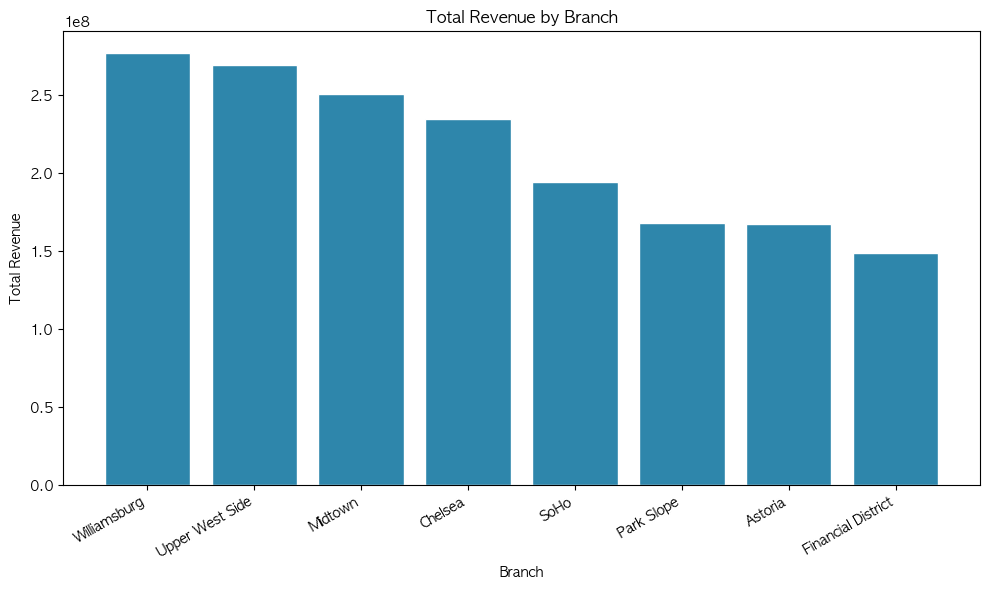

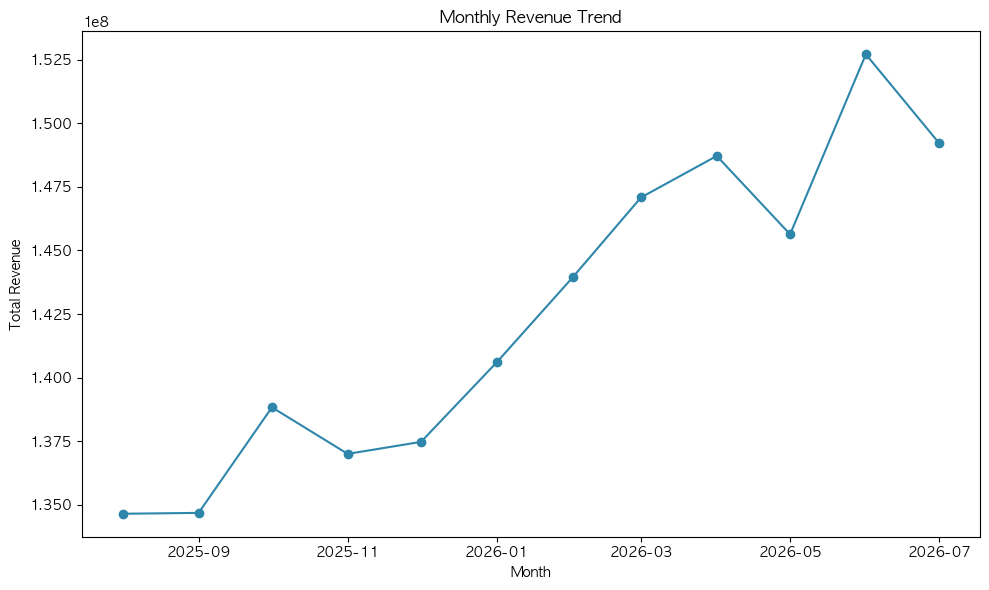

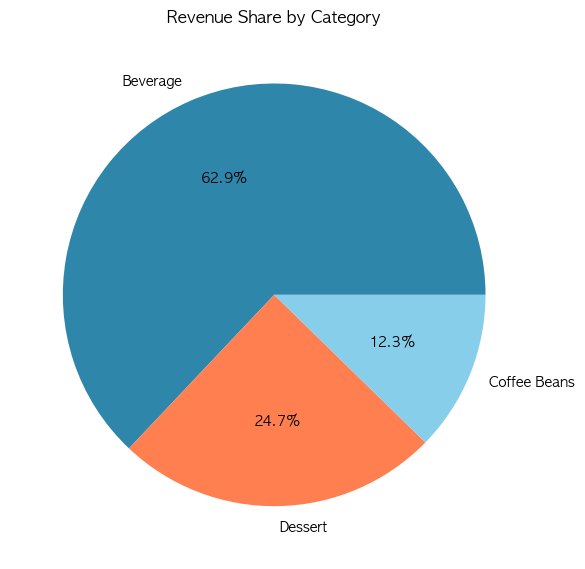

In [16]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Chart 1: Total revenue by branch (bar chart)
data = df.groupby("branch")["revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data.index, data.values, color="#2E86AB", edgecolor="white")
ax.set_title('Total Revenue by Branch')
ax.set_xlabel('Branch')
ax.set_ylabel('Total Revenue')
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Chart 2: Monthly revenue trend across all branches (line chart)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(month_revenue.index.to_timestamp(), month_revenue.values, color='#2E86AB', marker='o')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
plt.tight_layout()
plt.show()

# Bonus (optional): pie chart showing each category's share of total revenue
# (보너스: 카테고리별 매출 비중을 pie chart로)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(tbl['revenue'], labels=tbl.index, autopct='%1.1f%%', colors=['#2E86AB', '#FF7F50', '#87CEEB'])
ax.set_title('Revenue Share by Category')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
*What did I discover?*

- Store size is uneven: Williamsburg ~16% of company KRW, Financial District ~9%.  
  (지점 규모가 다름. Williamsburg 약 16%, Financial District 약 9%)
- Beverage is 62.9% of revenue; Coffee Beans is only 12.3% of KRW but the highest KRW per customer.  
  (음료가 매출 62.9%. 원두는 금액 12.3%지만 객단가는 가장 높음)
- Company sales **+10.8%** over 12 months, but SoHo is flat (**+0.6%**) while Financial District is **+20%** from a smaller base.  
  (전사 +10.8%. SoHo는 거의 제자리, FD는 작은 매장인데 +20%)


---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Do not give all eight stores the same KRW target — Williamsburg-scale and Financial District-scale are different boxes.  
   (8지점 동일 매출 목표 금지. 큰 매장과 작은 매장을 나눌 것)
2. Keep Beverage stocked and staffed; treat Coffee Beans as a high-spend add-on, not a volume driver.  
   (음료 재고·인력 우선. 원두는 객단가 높은 부가이지 객수 상품이 아님)
3. Ask why SoHo did not grow with the rest before treating the company +11% as “every store is fine.”  
   (전사 +11%를 전 지점 호조로 보지 말 것. SoHo 정체부터 확인)


---
# ❌ Mistakes
*What mistakes did I make today?*

- Read “full year” as calendar 2025 vs 2026 instead of the 12 months in the table.  
  (연간을 달력 연도로 읽음. 표의 12개월이 아니었음)
- Plotted PeriodIndex with `ax.plot` before `to_timestamp()`.  
  (Period를 timestamp로 안 바꾸고 plot)
- First bar chart used alphabetical branch order, not revenue order.  
  (막대를 매출순이 아니라 이름순으로 그림)


---
# ✅ What I Learned
*Today's biggest lesson*

- The groupby key must match the question: branch for Q1, category for Q2, month for Q3.  
  (groupby 축이 질문과 같아야 함)
- Share % = part / total. MoM % = `pct_change`. 12-month % = last / first - 1.  
  (비중은 부분÷전체. 전월 대비는 pct_change. 12개월은 마지막÷처음 - 1)
- Sort the bar chart the same way as the ranking table.  
  (막대 정렬은 순위 표와 같게)


---
# 🧠 Reflection

**What was difficult?**  
What “full year” meant, Period vs timestamp, and reading branch growth from several tables.  
(연간의 의미, Period vs timestamp, 지점 성장 표를 읽는 것)

**Why?**  
The file spans two calendar years but is one 12-month window. Matplotlib needs a point on a line, not a month box.  
(파일은 달력 연도 둘이지만 12개월 한 구간. matplotlib는 월 상자가 아니라 점이 필요함)

**How did I solve it?**  
`groupby("branch")` for the year total, `to_timestamp()` for Chart 2, `pct_change` within branch for store trends.  
(지점 합, 선 그래프는 timestamp, 지점 추이는 groupby("branch").pct_change)

**What would I do differently next time?**  
Check how many months sit in each year before comparing years. Sort bars before plotting.  
(연 비교 전에 개월 수 확인. 막대는 그리기 전에 정렬)


---
# ⭐ Self Evaluation

**Understanding**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
Bar vs line and share % are clearer; branch MoM tables still take time to read.  
(막대 vs 선, 비중 %는 이해됨. 지점 전월 대비 큰 표는 아직 읽는 데 시간이 걸림)

**Confidence**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
Can produce the assigned charts and a percent column. Less sure which extra table to show a stakeholder.  
(지정 차트와 퍼센트 열은 만들 수 있음. 이해관계자에게 어떤 추가 표를 줄지는 덜 확실)

**Difficulty**  
⭐⭐⭐⭐⭐☆☆☆☆☆  
Clean data; the hard parts were the meaning of “year” and the line-chart index.  
(데이터는 깨끗함. 어려운 부분은 ‘연간’의 뜻과 선 그래프 인덱스)


---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 05 — groupby and pivot (집계와 피벗)
